# 40) Sürekli Uniform Dağılımı
Sürekli Uniform Dağılım, belirli bir $[a, b]$ aralığındaki **tüm değerlerin eşit olasılık yoğunluğuna** sahip olduğu sürekli bir olasılık dağılımıdır. Kesikli Uniform'un (Konu 39) sürekli versiyonu gibi düşünülebilir — tek fark, artık ayrık değerler değil, bir aralıktaki **sonsuz** değer söz konusudur.

## Olasılık Yoğunluk Fonksiyonu (PDF)
$$f(x) = \frac{1}{b-a}, \quad a \le x \le b$$

Aralık dışındaki tüm değerler için $f(x) = 0$'dır. Bu fonksiyonun grafiği, $a$ ile $b$ arasında **düz, yatay bir çizgi** şeklindedir (Kesikli Uniform'un stem grafiğindeki düzlüğün, sürekli versiyonudur).

## Beklenen Değer ve Varyans
$$E(X) = \frac{a+b}{2} \qquad Var(X) = \frac{(b-a)^2}{12}$$

(Kesikli Uniform'daki formüllere çok benziyor, sadece varyans formülünde küçük bir fark var çünkü sürekli versiyonda "ardışık tam sayı sayısı" kavramı yok, direkt aralık genişliği kullanılıyor.)

## Kullanım Alanları
- Bir otobüsün durağa 0-10 dakika arasında herhangi bir anda eşit 
  olasılıkla gelmesi
- Rastgele bir ondalık sayı üretme (örn: `np.random.uniform(0,1)`)
- Bir sensörün ölçüm hatasının belirli bir aralıkta eşit dağılması

## Kesikli Uniform'dan Farkı
Kesikli Uniform'da "her değerin olasılığı" doğrudan okunabilirken (örn: zarda her yüzün olasılığı 1/6), Sürekli Uniform'da tek bir noktanın olasılığı her zaman **sıfırdır**. Anlamlı olan sadece bir **aralığın** olasılığıdır, ve bu aralık PDF'in altındaki **dikdörtgen alan** olarak hesaplanır.

Teorik Beklenen Değer: 5.0
Teorik Varyans: 8.333333333333334
Otobüsün 3-5 dakika arasında gelme olasılığı: 0.2

Deneysel Ortalama: 4.941595576842997
Deneysel Varyans: 8.27228165769653


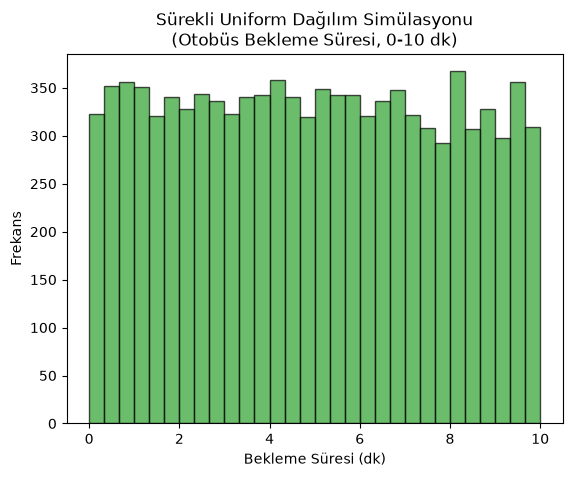

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Sürekli Uniform: Otobüs Bekleme Süresi Örneği ---
# Otobüs, 0-10 dakika arasında herhangi bir anda eşit olasılıkla gelebiliyor
a, b = 0, 10

# --- Teorik Değerler ---
teorik_E = (a + b) / 2
teorik_var = ((b - a) ** 2) / 12
print(f"Teorik Beklenen Değer: {teorik_E}")
print(f"Teorik Varyans: {teorik_var}")

# --- Belirli bir aralığın olasılığını hesaplama ---
# Örnek soru: Otobüsün 3 ile 5 dakika arasında gelme olasılığı nedir?
olasilik_3_5 = stats.uniform.cdf(5, loc=a, scale=b-a) - stats.uniform.cdf(3, loc=a, scale=b-a)
print(f"Otobüsün 3-5 dakika arasında gelme olasılığı: {olasilik_3_5}")

# --- Simülasyon ---
np.random.seed(42)
bekleme_sureleri = np.random.uniform(low=a, high=b, size=10000)

print(f"\nDeneysel Ortalama: {np.mean(bekleme_sureleri)}")
print(f"Deneysel Varyans: {np.var(bekleme_sureleri)}")

# --- Görselleştirme ---
plt.hist(bekleme_sureleri, bins=30, color='C2', edgecolor='black', alpha=0.7)
plt.title("Sürekli Uniform Dağılım Simülasyonu\n(Otobüs Bekleme Süresi, 0-10 dk)")
plt.xlabel("Bekleme Süresi (dk)")
plt.ylabel("Frekans")
plt.show()

### Sonuç
Teorik tanımda da dediğimiz üzere, a-b aralığında (bu örnekte otobüsün 0-10 dakika arası gelme olasılığı) rastgele ürettiğimiz uniform dağılıma göre 10000 gözlemlik değerlerin neredeyse eşit olasılıkta olduğunu görmekteyiz.